# CISM Tutorial 03: Analysis From The Serialized CISM Artifact

This notebook starts from the pickle artifact saved at the end of tutorial 02.

It follows the same general analysis direction as the existing `CISM_on_CRC.ipynb` workflow, but starts from the already-prepared CISM state instead of rebuilding the workflow from raw setup.

## What This Notebook Covers

In this notebook we will:

1. load the serialized artifact from tutorial 02
2. recover the selected analysis configuration
3. rebuild the discriminative motif result at the chosen state
4. show motif count vs stringency
5. draw the top 5 motifs ranked by `stringency * count`
6. compare motif-induced pairwise analysis to general pairwise analysis for each disease state
7. export the top-5 motif annotation files and exact-hit wide CSV files for downstream visualization and analysis

In [21]:
from pathlib import Path
import pickle

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from cism import (
    DiscriminativeFeatureKey,
    export_top_motif_visualization_inputs,
    rank_motifs_by_stringency_count,
    motif_to_annotation_text,
)
from cism.cism import GetMotifsResult
from cism.helpers import create_weight_matrix_from_motifs, string_base64_pickle
from cism.vis.draw import draw_motif
from pairwise import GraphReader, PairwiseAnalysis


In [22]:
def find_project_root(start=None):
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "cism").exists() and (candidate / "melanoma_tutorials").exists():
            return candidate
    raise FileNotFoundError("Could not find the repository root from the current notebook path.")


PROJECT_ROOT = find_project_root()
MELANOMA_TUTORIAL_DIR = PROJECT_ROOT / "melanoma_tutorials"

# Tutorial 02 writes into this nested runtime folder when run from melanoma_tutorials/.
TUTORIAL_RUNTIME_DIR = MELANOMA_TUTORIAL_DIR / "melanoma_tutorials" / "runtime"
if not (TUTORIAL_RUNTIME_DIR / "serialized" / "Melanoma_cism_ready.pkl").exists():
    # Fallback for reruns that use the non-nested runtime layout.
    fallback_runtime_dir = MELANOMA_TUTORIAL_DIR / "runtime"
    if (fallback_runtime_dir / "serialized" / "Melanoma_cism_ready.pkl").exists():
        TUTORIAL_RUNTIME_DIR = fallback_runtime_dir

SERIALIZED_ROOT = TUTORIAL_RUNTIME_DIR / "serialized"
ANALYSIS_OUTPUT_ROOT = TUTORIAL_RUNTIME_DIR / "analysis_outputs"
TOP_MOTIF_EXPORT_ROOT = ANALYSIS_OUTPUT_ROOT / "motif_visualization_inputs"

ANALYSIS_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
TOP_MOTIF_EXPORT_ROOT.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Melanoma tutorial directory: {MELANOMA_TUTORIAL_DIR}")
print(f"Serialized artifact directory: {SERIALIZED_ROOT}")
print(f"Analysis output directory: {ANALYSIS_OUTPUT_ROOT}")
print(f"Top motif export directory: {TOP_MOTIF_EXPORT_ROOT}")


Project root: /home/omriavit/CISM/CISM_paper_revision
Melanoma tutorial directory: /home/omriavit/CISM/CISM_paper_revision/melanoma_tutorials
Serialized artifact directory: /home/omriavit/CISM/CISM_paper_revision/melanoma_tutorials/melanoma_tutorials/runtime/serialized
Analysis output directory: /home/omriavit/CISM/CISM_paper_revision/melanoma_tutorials/melanoma_tutorials/runtime/analysis_outputs
Top motif export directory: /home/omriavit/CISM/CISM_paper_revision/melanoma_tutorials/melanoma_tutorials/runtime/analysis_outputs/motif_visualization_inputs


## Load The Artifact From Tutorial 02

Choose the `.pkl` created in tutorial 02.

Example filename:

- `example_dataset_cism_ready.pkl`

In [23]:
# Artifact file created by tutorial 02.
artifact_path = SERIALIZED_ROOT / "Melanoma_cism_ready.pkl"
if not artifact_path.exists():
    raise FileNotFoundError(
        f"Could not find tutorial 02 artifact at {artifact_path}. "
        "Run melanoma_tutorials/02_fanmod_and_cism_initialization.ipynb first."
    )

with artifact_path.open("rb") as handle:
    artifact = pickle.load(handle)

artifact.keys()


dict_keys(['cism', 'discriminator', 'best_feature_conf', 'tuning_best_params', 'tuning_best_score', 'tuning_trials_df', 'network_dataset_root_path', 'dataset_folder', 'dataset_name', 'fanmod_path', 'fanmod_exe', 'fanmod_output_root_path', 'fanmod_cache_root_path', 'tissue_state_csv_path', 'tissue_state_to_string', 'tissue_state_mode', 'survival_rate_cutoff', 'common_cells_type', 'labels', 'missing_tissue_state'])

In [24]:
cism = artifact["cism"]
discriminator = artifact["discriminator"]
best_feature_conf = artifact["best_feature_conf"]
network_dataset_root_path = artifact["network_dataset_root_path"]
dataset_folder = artifact["dataset_folder"]
fanmod_output_root_path = artifact["fanmod_output_root_path"]
fanmod_cache_root_path = artifact["fanmod_cache_root_path"]
tissue_state_csv_path = artifact["tissue_state_csv_path"]
tissue_state_to_string = artifact["tissue_state_to_string"]
common_cells_type = artifact["common_cells_type"]
labels = artifact["labels"]

survival_rate_cutoff = artifact.get("survival_rate_cutoff", 1000)


def map_survival_rate_to_class(survival_rate: int):
    if survival_rate < survival_rate_cutoff:
        return "Short-term survival"
    return "Long-term survival"


tissue_state_func = map_survival_rate_to_class if tissue_state_to_string is None else None

dataset_dir = Path(network_dataset_root_path) / dataset_folder

print(f"dataset_dir = {dataset_dir}")
print(f"labels = {labels}")
#print(f"best_feature_conf.shared_percentage = {best_feature_conf.shared_percentage}")
#print(f"best_feature_conf.max_class_features = {best_feature_conf.max_class_features}")


dataset_dir = /home/omriavit/CISM/CISM_paper_revision/melanoma_tutorials/pet_data/Melanoma
labels = ['NN', 'NP']


## Rebuild The Current Discriminative Motif Result

We use the discriminator stored in the artifact and reconstruct the discriminative motif table for the selected classes.

In [25]:
discover_result = discriminator.discover(
    extract_by=DiscriminativeFeatureKey.STRUCTURE_AND_CELL_IDENTITIES,
    classes=labels,
)

discriminative_motifs_df = discover_result.get_discriminative_motifs().copy()
display(discriminative_motifs_df.head())


,Patient,FOV,ID,Freq,Count,Mean_Freq,STD,z_score,p_value,motif,nunique_colors,Disease,Patient_uId,colors_vec,colors_vec_hash,patient_class,patient_count,patient_percentage
254359,10,FOV116,33631184364,0.000085,34.0,0.000039,0.000011,4.1050,0.000,gASVYQEAAAAAAACMGG5ldHdvcmt4LmNsYXNzZXMuZGlncm...,4,Melanoma,Melanoma10,"[0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1]",-5651031001857266404,NP,1,0.055556
255186,10,FOV116,1085320396,0.000055,22.0,0.000009,0.000005,9.1606,0.000,gASVXwEAAAAAAACMGG5ldHdvcmt4LmNsYXNzZXMuZGlncm...,4,Melanoma,Melanoma10,"[1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]",-7645543494879028022,NP,1,0.055556
255394,10,FOV116,5984442860,0.000050,20.0,0.000027,0.000008,2.9710,0.002,gASVYQEAAAAAAACMGG5ldHdvcmt4LmNsYXNzZXMuZGlncm...,4,Melanoma,Melanoma10,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1]",-7034315530593046404,NP,2,0.111111
255451,10,FOV116,5393451212,0.000048,19.0,0.000015,0.000009,3.5409,0.005,gASVXQEAAAAAAACMGG5ldHdvcmt4LmNsYXNzZXMuZGlncm...,3,Melanoma,Melanoma10,"[0, 1, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0]",272304140341507573,NP,3,0.166667
255850,10,FOV116,5433369996,0.000040,16.0,0.000002,0.000003,13.8050,0.000,gASVXwEAAAAAAACMGG5ldHdvcmt4LmNsYXNzZXMuZGlncm...,4,Melanoma,Melanoma10,"[0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0]",6424817341558394680,NP,5,0.277778


## Motif Count Vs Stringency Scatter Plot

We aggregate each motif by:

- `stringency = max(patient_percentage)`
- `total_count = sum(Count)`

This gives a compact view of motif recurrence versus discrimination stringency.

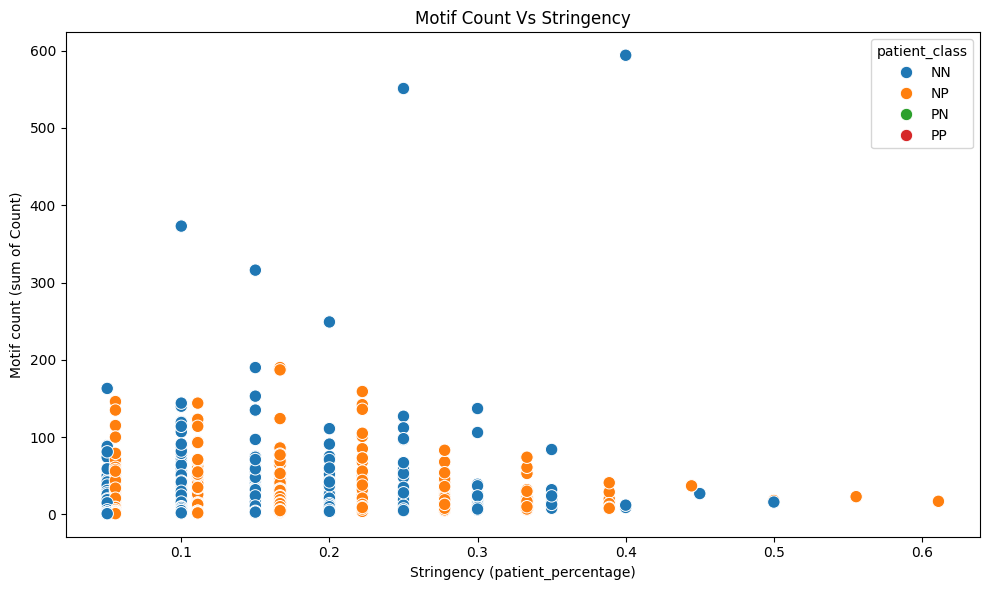

,ID,stringency,total_count,patient_class
13052,25563453932,0.611111,17.0,NP
2163,2968124908,0.555556,23.0,NP
3441,4040914412,0.500000,18.0,NP
13082,25571793292,0.500000,16.0,NN
164,560552428,0.450000,27.0,NN
2033,2529945068,0.444444,37.0,NP
8579,12124834092,0.400000,594.0,NN
11836,20719512972,0.400000,12.0,NN
10327,16416115020,0.400000,9.0,NN
12093,21257884140,0.388889,41.0,NP


In [26]:
motif_count_vs_stringency = (
    discriminative_motifs_df.groupby("ID", observed=True)
    .agg(
        stringency=("patient_percentage", "max"),
        total_count=("Count", "sum"),
        patient_class=("patient_class", lambda values: values.mode().iloc[0]),
    )
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=motif_count_vs_stringency,
    x="stringency",
    y="total_count",
    hue="patient_class",
    s=80,
)
plt.xlabel("Stringency (patient_percentage)")
plt.ylabel("Motif count (sum of Count)")
plt.title("Motif Count Vs Stringency")
plt.tight_layout()
plt.show()

display(motif_count_vs_stringency.sort_values(["stringency", "total_count"], ascending=False).head(20))


## Top 5 Motifs By `Stringency * Count`

We now rank motifs by the combined score:

```text
score = stringency * total_count
```

This gives the 5 motifs we will draw and export.

In [27]:
top5_motifs_df = rank_motifs_by_stringency_count(discover_result=discover_result, top_k=5)
display(top5_motifs_df)


,ID,stringency,total_count,motif,patient_class,score
0,12124834092,0.40,594.0,gASVXQEAAAAAAACMGG5ldHdvcmt4LmNsYXNzZXMuZGlncm...,NN,237.60
1,12116445484,0.25,551.0,gASVXQEAAAAAAACMGG5ldHdvcmt4LmNsYXNzZXMuZGlncm...,NN,137.75
2,5970219308,0.20,249.0,gASVXQEAAAAAAACMGG5ldHdvcmt4LmNsYXNzZXMuZGlncm...,NN,49.80
3,6755020076,0.15,316.0,gASVXQEAAAAAAACMGG5ldHdvcmt4LmNsYXNzZXMuZGlncm...,NN,47.40
4,11044218156,0.30,137.0,gASVXwEAAAAAAACMGG5ldHdvcmt4LmNsYXNzZXMuZGlncm...,NN,41.10


In [28]:
def load_motif_graph(motif_value):
    if isinstance(motif_value, str):
        return string_base64_pickle(motif_value)
    return motif_value


Motif ID: 12124834092
Class: NN
Stringency: 0.4000
Total count: 594
Score = stringency * count: 237.6000
A.type = blood vessels
B.type = cd8 t cell
C.type = memory%cd4 t cell
D.type = memory%cd4 t cell
A -> B
A -> C
B -> D



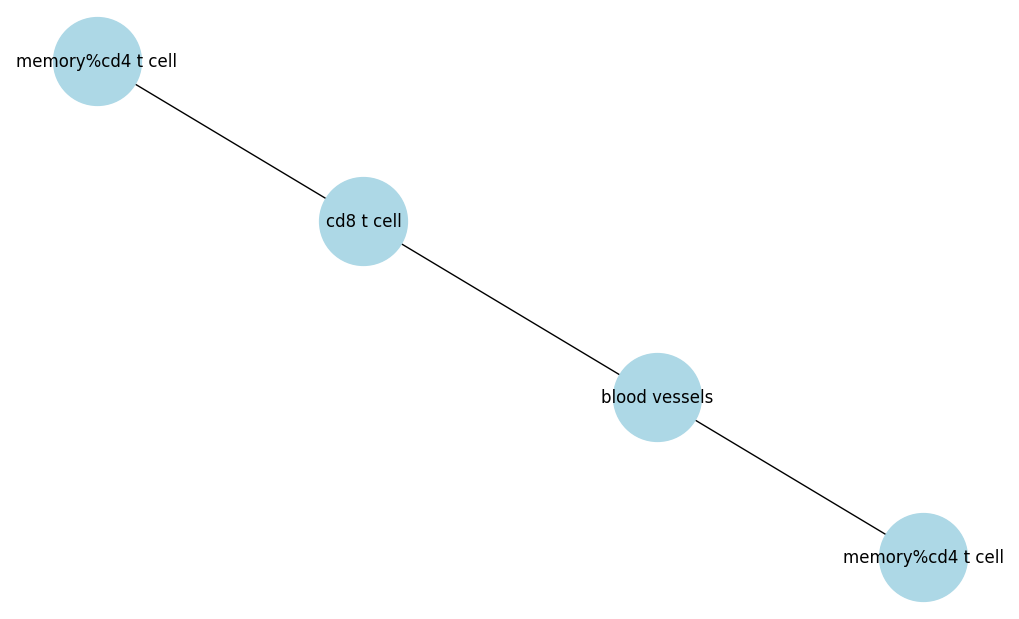

Motif ID: 12116445484
Class: NN
Stringency: 0.2500
Total count: 551
Score = stringency * count: 137.7500
A.type = blood vessels
B.type = cd4 t cell
C.type = memory%cd4 t cell
D.type = memory%cd4 t cell
A -> B
A -> C
B -> D



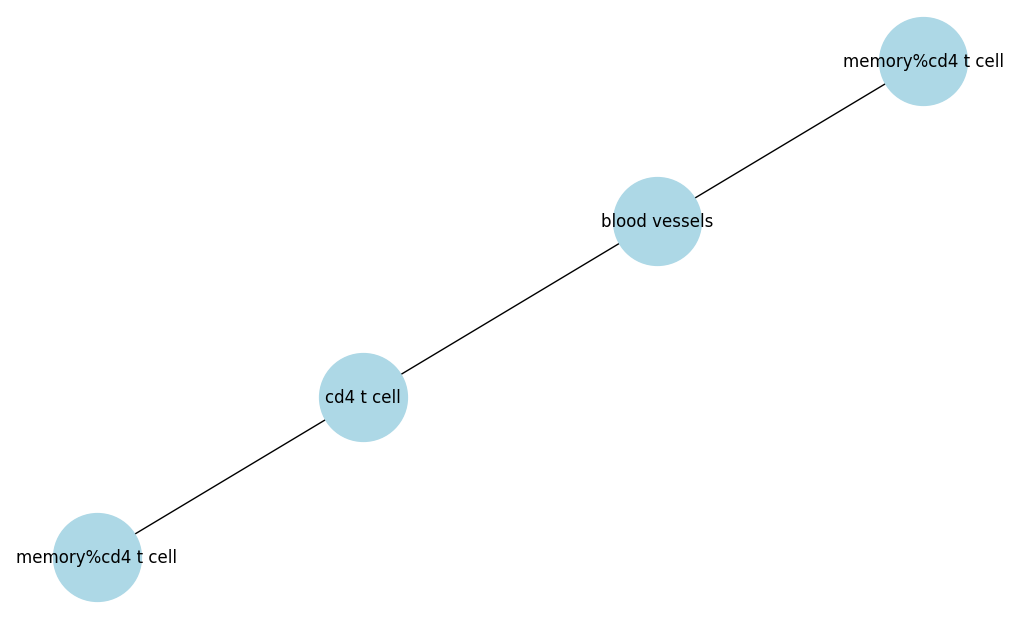

Motif ID: 5970219308
Class: NN
Stringency: 0.2000
Total count: 249
Score = stringency * count: 49.8000
A.type = b cell
B.type = hevs
C.type = memory%cd4 t cell
D.type = memory%cd4 t cell
A -> C
A -> D
B -> C



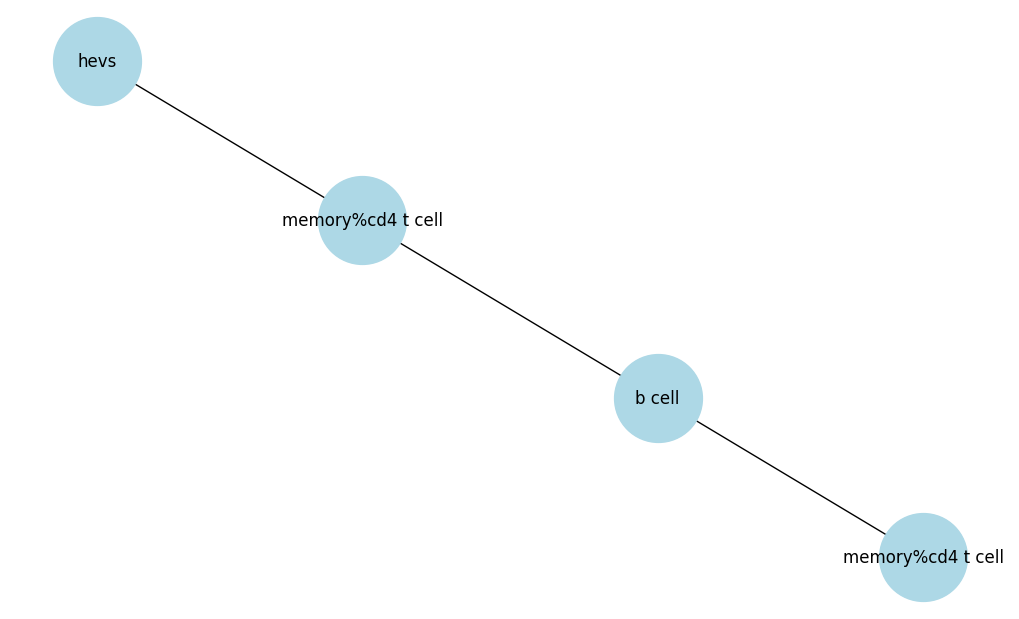

Motif ID: 6755020076
Class: NN
Stringency: 0.1500
Total count: 316
Score = stringency * count: 47.4000
A.type = b cell
B.type = cd8 t cell
C.type = cd8 t cell
D.type = memory%cd4 t cell
A -> B
B -> D
C -> D



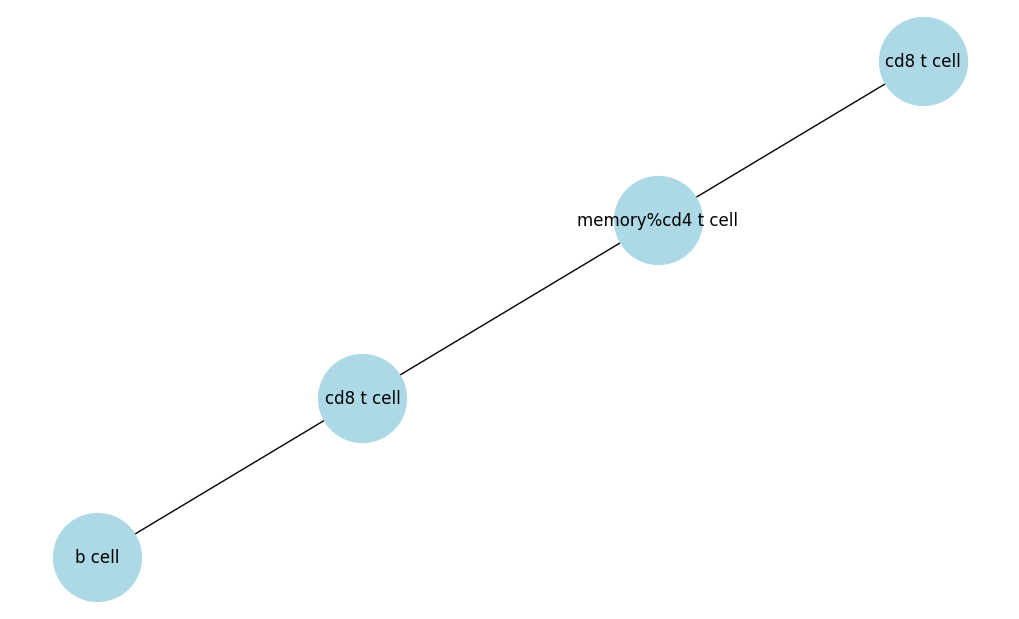

Motif ID: 11044218156
Class: NN
Stringency: 0.3000
Total count: 137
Score = stringency * count: 41.1000
A.type = blood vessels
B.type = cd4 t cell
C.type = cd8 t cell
D.type = memory%cd4 t cell
A -> B
B -> C
C -> D



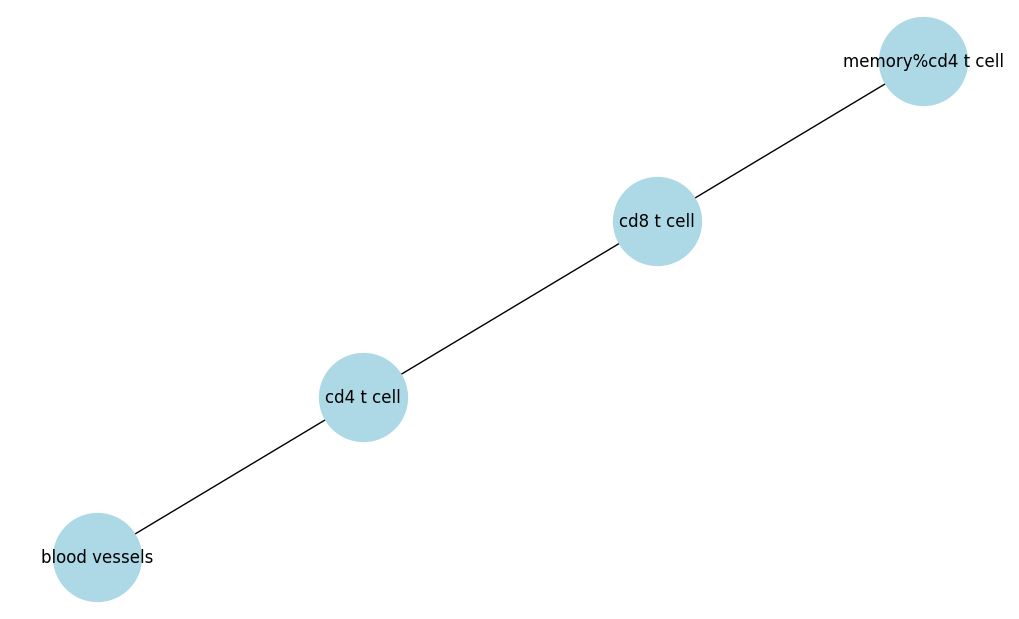

: 

In [ ]:
for _, row in top5_motifs_df.iterrows():
    motif_id = int(row["ID"])
    motif_graph = load_motif_graph(row["motif"])

    print(f"Motif ID: {motif_id}")
    print(f"Class: {row['patient_class']}")
    print(f"Stringency: {row['stringency']:.4f}")
    print(f"Total count: {row['total_count']:.0f}")
    print(f"Score = stringency * count: {row['score']:.4f}")
    print(motif_to_annotation_text(motif_graph, common_cells_type))
    draw_motif(motif_graph, common_cells_type)


## Recover The Selected Feature Space

To compare motif-induced pairwise structure to general pairwise structure, we first recover the motif set selected by the chosen analysis configuration.

In [ ]:
motif_space_features = discriminator.get_features(
    feature_conf=best_feature_conf,
    exclude_patients=[],
    n_jobs=12,
    prefer="processes",
)

motif_result = GetMotifsResult(
    motif_space_features=motif_space_features,
    discriminator=discriminator,
    classes=labels,
)

motifs_by_class = motif_result.get_motifs_by_class()
motif_mean_weight = motif_result.get_motifs_mean_weight()

print(motifs_by_class)


  0%|          | 0/38 [00:00<?, ?it/s]

## General Pairwise Analysis Per Disease State

This mirrors the pairwise part of the CRC workflow, but uses the serialized analysis state and the prepared txt graph dataset.

In [ ]:
full_graph_df = pd.DataFrame()
full_graph_df = GraphReader.get_graphs(
    full_graph_df=full_graph_df,
    raw_data_folder=network_dataset_root_path,
    raw_data_folder_type=f"/{dataset_folder}",
    disease=artifact.get("dataset_name", dataset_folder),
    cells_type=common_cells_type,
)

pairwise_analysis = PairwiseAnalysis(
    tissue_state_csv_path=tissue_state_csv_path,
    tissue_state_to_string=tissue_state_to_string,
    tissue_state_func=tissue_state_func,
)

display(full_graph_df.head())


In [ ]:
general_pairwise_by_class = {
    patient_class: pairwise_analysis.get_pairwise_counter(
        full_graph_df=full_graph_df,
        patient_class=patient_class,
        cells_type=common_cells_type,
        normalize=True,
    )
    for patient_class in labels
}

for patient_class, matrix in general_pairwise_by_class.items():
    #display(matrix)
    pairwise_analysis.plot_pairwise_heatmap(
        full_graph_df=full_graph_df,
        patient_class=patient_class,
        cells_type=common_cells_type,
        normalize=True,
        annotate=False,
    )


## Motif-Induced Pairwise Analysis Per Disease State

Now we derive pairwise cell-type interaction structure induced only by the selected motif set.

In [ ]:
motif_induced_pairwise_by_class = {
    patient_class: create_weight_matrix_from_motifs(
        discriminator=discriminator,
        cells_type=common_cells_type,
        cell_identity_to_motif_hash=motif_result.cell_identity_to_motif_hash,
        motifs_ids=motifs_by_class[patient_class],
        motifs_weight=motif_mean_weight,
    )
    for patient_class in labels
}

for patient_class, matrix in motif_induced_pairwise_by_class.items():
    #display(matrix)
    plt.figure(figsize=(8, 6))
    sns.heatmap(matrix, cmap="viridis")
    plt.title(f"Motif-induced pairwise interactions for {patient_class}")
    plt.xlabel("Target Cell Type")
    plt.ylabel("Source Cell Type")
    plt.tight_layout()
    plt.show()


## Compare Motif-Induced Vs General Pairwise Structure

For each disease state, we compare the global pairwise background to the pairwise structure induced by the selected motifs.

In [ ]:
pairwise_comparison = {}
for patient_class in labels:
    general_matrix = general_pairwise_by_class[patient_class]
    motif_matrix = motif_induced_pairwise_by_class[patient_class]
    difference_matrix = motif_matrix - general_matrix
    pairwise_comparison[patient_class] = {
        "general": general_matrix,
        "motif_induced": motif_matrix,
        "difference": difference_matrix,
    }

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    sns.heatmap(general_matrix, cmap="viridis", ax=axes[0])
    axes[0].set_title(f"General pairwise: {patient_class}")

    sns.heatmap(motif_matrix, cmap="viridis", ax=axes[1])
    axes[1].set_title(f"Motif-induced pairwise: {patient_class}")

    sns.heatmap(difference_matrix, cmap="coolwarm", center=0, ax=axes[2])
    axes[2].set_title(f"Difference: motif-induced - general ({patient_class})")

    for ax in axes:
        ax.set_xlabel("Target Cell Type")
        ax.set_ylabel("Source Cell Type")

    plt.tight_layout()
    plt.show()


## Export Visualization Inputs For The Top 5 Motifs

This step creates, for each of the top 5 motifs:

- `<motif_id>.txt`
- `<motif_id>_hits_wide.csv`

These match the annotation/hit-table format you showed and can be reused for motif visualization and later post-processing.

### Dataset-Specific Input Needed Here

The hit-finder works on the original cell-level CSV, so set that path and the relevant column names below.

Replace the defaults with the actual file and schema for your dataset.

In [ ]:
# Optional: replace with the original melanoma cell-level CSV if you have one.
raw_cells_csv_path = MELANOMA_TUTORIAL_DIR / "pet_data" / "Melanoma" / "raw_cells.csv"

# Replace these column names as needed for your dataset.
fov_col = "fov"
id_col = "cell_id"
x_col = "centroid-0"
y_col = "centroid-1"
type_col = "pred"
class_col = "Group"
patient_col = "patient number"

# Usually keep this aligned with the classes stored in the artifact.
export_classes = labels


In [ ]:
top_motif_export_df = export_top_motif_visualization_inputs(
    discriminator=discriminator,
    discover_result=discover_result,
    raw_cells_csv_path=raw_cells_csv_path,
    output_dir=str(TOP_MOTIF_EXPORT_ROOT),
    top_k=5,
    fov_col=fov_col,
    id_col=id_col,
    x_col=x_col,
    y_col=y_col,
    type_col=type_col,
    classes=export_classes,
    patient_col=patient_col,
    induced=False,
)

display(top_motif_export_df)


## Output Summary

This notebook leaves you with:

- analysis plots
- pairwise comparison matrices
- the top 5 motifs drawn from the selected discriminative state
- annotation text files and exact-hit CSV files for those motifs

In [ ]:
print("Notebook 03 summary:")
print(f"artifact_path = {artifact_path}")
print(f"dataset_dir = {dataset_dir}")
print(f"top motif export directory = {TOP_MOTIF_EXPORT_ROOT}")
print(f"top 5 motif ids = {top5_motifs_df['ID'].tolist()}")
print(f"best shared_percentage = {best_feature_conf.shared_percentage}")
print(f"best max_class_features = {best_feature_conf.max_class_features}")


## Ready For The Next Step

At this point, we can continue into deeper post-processing and visualization using:

- the saved CISM/discriminator artifact
- the pairwise comparison outputs
- the top-motif annotation files
- the top-motif hit tables

This is the right point to branch into the additional analysis ideas you want to add next.